### Step 0 :- Import Libraries

In [1]:
# Import Pandas
import pandas as pd

# Import NumPy
import numpy as np

# Import Matplotlib
import matplotlib.pyplot as plt

# Import train-test split
from sklearn.model_selection import train_test_split

# Import Linear Regression
from sklearn.linear_model import LinearRegression

# Import Label Encoder
from sklearn.preprocessing import LabelEncoder

# Import model evaluation metrics
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score)

### Step 1 :- Load Dataset

#### Load Dataset

In [2]:
# Load dataset
insurance_data = pd.read_csv('insurance.csv')

#### Display Dataset Information

In [3]:
# Display dataset shape
print(f'Dataset Shape: {insurance_data.shape}')

# Display column names
print(f'\nColumns:\n{insurance_data.columns}')

# Display first 5 rows
insurance_data.head()

Dataset Shape: (1338, 7)

Columns:
Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='str')


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


#### Check Dataset Information

In [4]:
# Display dataset information
insurance_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 94.5 KB


#### Display Last 5 Rows

In [5]:
# Display last 5 rows
insurance_data.tail()

,age,sex,bmi,children,smoker,region,charges
1333,50,male,30.97,3,no,northwest,10600.5483
1334,18,female,31.92,0,no,northeast,2205.9808
1335,18,female,36.85,0,no,southeast,1629.8335
1336,21,female,25.80,0,no,southwest,2007.9450
1337,61,female,29.07,0,yes,northwest,29141.3603


#### Display Random 5 Rows

In [6]:
# Display random 5 rows
insurance_data.sample(5, random_state = 42)

,age,sex,bmi,children,smoker,region,charges
764,45,female,25.175,2,no,northeast,9095.06825
887,36,female,30.020,0,no,northwest,5272.17580
890,64,female,26.885,0,yes,northwest,29330.98315
1293,46,male,25.745,3,no,northwest,9301.89355
259,19,male,31.920,0,yes,northwest,33750.29180


#### Display Dataset Dimensions

In [7]:
# Display dataset dimensions
print(f'Rows: {insurance_data.shape[0]}')

print(f'Columns: {insurance_data.shape[1]}')

Rows: 1338
Columns: 7


#### Display Data Types

In [8]:
# Display data types
insurance_data.dtypes

age           int64
sex             str
bmi         float64
children      int64
smoker          str
region          str
charges     float64
dtype: object

#### Display Memory Usage

In [9]:
# Display memory usage
print(f'Memory Usage: {insurance_data.memory_usage(deep = True).sum() / 1024:.2f} KB')

Memory Usage: 94.46 KB


### Step 2 :- Exploratory Data Analysis

#### Display First 5 Rows

In [10]:
# Display first 5 rows
insurance_data.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


#### Display Last 5 Rows

In [11]:
# Display last 5 rows
insurance_data.tail()

,age,sex,bmi,children,smoker,region,charges
1333,50,male,30.97,3,no,northwest,10600.5483
1334,18,female,31.92,0,no,northeast,2205.9808
1335,18,female,36.85,0,no,southeast,1629.8335
1336,21,female,25.80,0,no,southwest,2007.9450
1337,61,female,29.07,0,yes,northwest,29141.3603


#### Display Random 5 Rows

In [12]:
# Display random 5 rows
insurance_data.sample(5, random_state = 42)

,age,sex,bmi,children,smoker,region,charges
764,45,female,25.175,2,no,northeast,9095.06825
887,36,female,30.020,0,no,northwest,5272.17580
890,64,female,26.885,0,yes,northwest,29330.98315
1293,46,male,25.745,3,no,northwest,9301.89355
259,19,male,31.920,0,yes,northwest,33750.29180


#### Display Dataset Shape

In [13]:
# Display dataset shape
print(f'Rows: {insurance_data.shape[0]}')

print(f'Columns: {insurance_data.shape[1]}')

Rows: 1338
Columns: 7


#### Display Data Types

In [14]:
# Display data types
insurance_data.dtypes

age           int64
sex             str
bmi         float64
children      int64
smoker          str
region          str
charges     float64
dtype: object

#### Check Missing Values

In [15]:
# Display missing values
insurance_data.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

#### Check Duplicate Records

In [16]:
# Display duplicate records
print(f'Duplicate Records: {insurance_data.duplicated().sum()}')

Duplicate Records: 1


#### Display Summary Statistics

In [17]:
# Display summary statistics
insurance_data.describe(include = 'all')

,age,sex,bmi,children,smoker,region,charges
count,1338.000000,1338,1338.000000,1338.000000,1338,1338,1338.000000
unique,NaN,2,NaN,NaN,2,4,NaN
top,NaN,male,NaN,NaN,no,southeast,NaN
freq,NaN,676,NaN,NaN,1064,364,NaN
mean,39.207025,NaN,30.663397,1.094918,NaN,NaN,13270.422265
std,14.049960,NaN,6.098187,1.205493,NaN,NaN,12110.011237
min,18.000000,NaN,15.960000,0.000000,NaN,NaN,1121.873900
25%,27.000000,NaN,26.296250,0.000000,NaN,NaN,4740.287150
50%,39.000000,NaN,30.400000,1.000000,NaN,NaN,9382.033000
75%,51.000000,NaN,34.693750,2.000000,NaN,NaN,16639.912515


#### Age Distribution

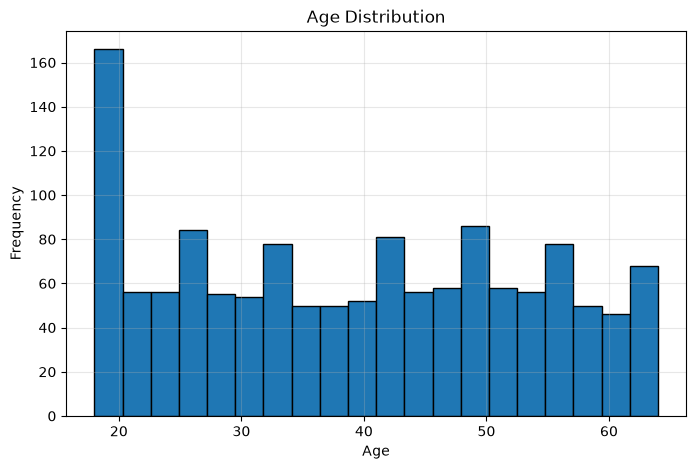

In [18]:
# Create figure
plt.figure(figsize = (8, 5))

# Plot age distribution
plt.hist(

    insurance_data['age'],

    bins = 20,

    edgecolor = 'black')

# Chart title
plt.title('Age Distribution')

# X-axis label
plt.xlabel('Age')

# Y-axis label
plt.ylabel('Frequency')

# Show grid
plt.grid(alpha = 0.3)

# Display chart
plt.show()

#### BMI Distribution

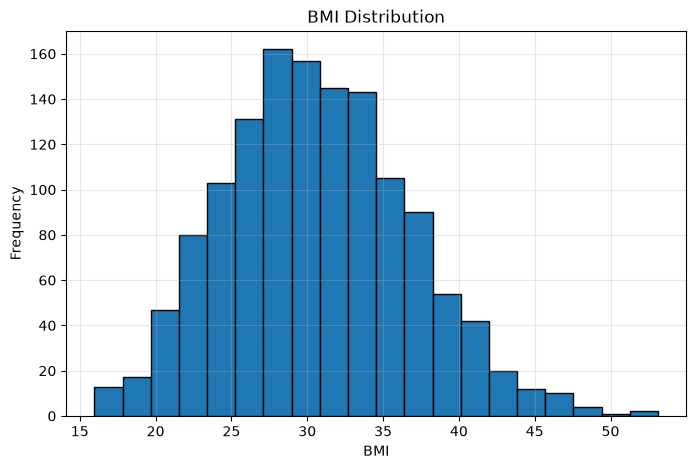

In [19]:
# Create figure
plt.figure(figsize = (8, 5))

# Plot BMI distribution
plt.hist(

    insurance_data['bmi'],

    bins = 20,

    edgecolor = 'black')

# Chart title
plt.title('BMI Distribution')

# X-axis label
plt.xlabel('BMI')

# Y-axis label
plt.ylabel('Frequency')

# Show grid
plt.grid(alpha = 0.3)

# Display chart
plt.show()

#### Medical Charges Distribution

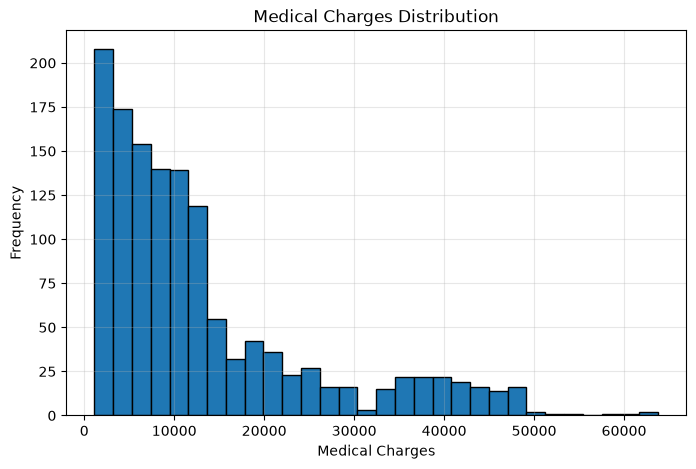

In [20]:
# Create figure
plt.figure(figsize = (8, 5))

# Plot medical charges distribution
plt.hist(

    insurance_data['charges'],

    bins = 30,

    edgecolor = 'black')

# Chart title
plt.title('Medical Charges Distribution')

# X-axis label
plt.xlabel('Medical Charges')

# Y-axis label
plt.ylabel('Frequency')

# Show grid
plt.grid(alpha = 0.3)

# Display chart
plt.show()

#### Correlation Matrix

In [21]:
# Display correlation matrix
insurance_data.corr(numeric_only = True)

,age,bmi,children,charges
age,1.000000,0.109272,0.042469,0.299008
bmi,0.109272,1.000000,0.012759,0.198341
children,0.042469,0.012759,1.000000,0.067998
charges,0.299008,0.198341,0.067998,1.000000


#### Correlation Heatmap

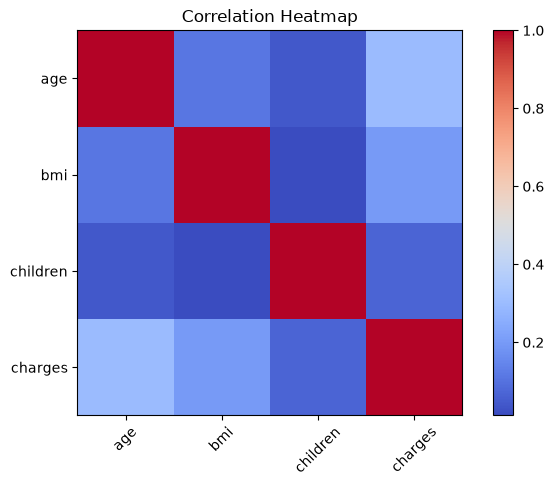

In [22]:
# Create figure
plt.figure(figsize = (8, 5))

# Display correlation heatmap
plt.imshow(

    insurance_data.corr(

        numeric_only = True

    ),

    cmap = 'coolwarm')

# Display color bar
plt.colorbar()

# Set x-axis labels
plt.xticks(

    range(

        len(

            insurance_data.corr(

                numeric_only = True

            ).columns

        )

    ),

    insurance_data.corr(

        numeric_only = True

    ).columns,

    rotation = 45)

# Set y-axis labels
plt.yticks(

    range(

        len(

            insurance_data.corr(

                numeric_only = True

            ).columns

        )

    ),

    insurance_data.corr(

        numeric_only = True

    ).columns)

# Chart title
plt.title('Correlation Heatmap')

# Display chart
plt.show()

#### Smoker Distribution

In [23]:
insurance_data['smoker'].value_counts()

smoker
no     1064
yes     274
Name: count, dtype: int64

#### Region Distribution

In [24]:
insurance_data['region'].value_counts()

region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64

### Step 3 :- Data Preprocessing

#### Check Missing Values

In [25]:
# Display missing values
insurance_data.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

#### Fill Missing Values

In [26]:
# Fill missing values
insurance_data = insurance_data.fillna(

    insurance_data.median(

        numeric_only = True))

#### Check Duplicate Records

In [27]:
# Display duplicate records
print(f'Duplicate Records: {insurance_data.duplicated().sum()}')

Duplicate Records: 1


#### Remove Duplicate Records

In [28]:
# Remove duplicate records
insurance_data = insurance_data.drop_duplicates()

# Display duplicate records
print(f'Duplicate Records: {insurance_data.duplicated().sum()}')

Duplicate Records: 0


#### Encode Categorical Features

In [29]:
# Create label encoder
label_encoder = LabelEncoder()

# Encode categorical columns
insurance_data['sex'] = label_encoder.fit_transform(

    insurance_data['sex'])

insurance_data['smoker'] = label_encoder.fit_transform(

    insurance_data['smoker'])

insurance_data['region'] = label_encoder.fit_transform(

    insurance_data['region'])

# Display first 5 rows
insurance_data.head()

,age,sex,bmi,children,smoker,region,charges
0,19,0,27.900,0,1,3,16884.92400
1,18,1,33.770,1,0,2,1725.55230
2,28,1,33.000,3,0,2,4449.46200
3,33,1,22.705,0,0,1,21984.47061
4,32,1,28.880,0,0,1,3866.85520


#### Check Data Types

In [30]:
# Display data types
insurance_data.dtypes

age           int64
sex           int64
bmi         float64
children      int64
smoker        int64
region        int64
charges     float64
dtype: object

#### Separate Features and Target

In [31]:
# Separate features and target
features = insurance_data.drop(

    'charges',

    axis = 1)

target = insurance_data['charges']

#### Split Training and Testing Data

In [32]:
# Split dataset
X_train, X_test, y_train, y_test = train_test_split(

    features,

    target,

    test_size = 0.2,

    random_state = 42)

#### Display Dataset Shape

In [33]:
# Display dataset shape
print(f'Training Features: {X_train.shape}')

print(f'Testing Features: {X_test.shape}')

print(f'Training Target: {y_train.shape}')

print(f'Testing Target: {y_test.shape}')

Training Features: (1069, 6)
Testing Features: (268, 6)
Training Target: (1069,)
Testing Target: (268,)


### Step 4 :- Model Training

#### Create Linear Regression Model

In [34]:
# Create linear regression model
linear_regression_model = LinearRegression()

#### Train Model

In [35]:
# Train model
linear_regression_model.fit(

    X_train,

    y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](6,)","[ 248.76, -99.7 , 312.61, 534.12,23052.15, -237.63]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](6,)","['age','sex','bmi','children','smoker','region']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-1.105e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,6
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,6


#### Display Feature Coefficients

In [36]:
# Create feature coefficients dataframe
coefficients = pd.DataFrame({

    'Feature': X_train.columns,

    'Coefficient': linear_regression_model.coef_})

coefficients

,Feature,Coefficient
0,age,248.764071
1,sex,-99.695394
2,bmi,312.609045
3,children,534.120877
4,smoker,23052.152752
5,region,-237.625147


#### Sort Feature Coefficients

In [37]:
# Sort feature coefficients
coefficients = coefficients.sort_values(

    by = 'Coefficient',

    ascending = False)

coefficients

,Feature,Coefficient
4,smoker,23052.152752
3,children,534.120877
2,bmi,312.609045
0,age,248.764071
1,sex,-99.695394
5,region,-237.625147


#### Display most important feature

In [38]:
# Display most important feature
print(f'Most Important Feature: {coefficients.iloc[0]["Feature"]}')

Most Important Feature: smoker


#### Display Model Intercept

In [39]:
# Display model intercept
print(f'Intercept: {linear_regression_model.intercept_:.2f}')

Intercept: -11047.69


#### Display Total Features

In [40]:
# Display total features
print(f'Total Features: {X_train.shape[1]}')

Total Features: 6


#### Display Training R² Score

In [41]:
# Calculate training score
training_score = linear_regression_model.score(

    X_train,

    y_train)

print(f'Training R² Score: {training_score:.4f}')

Training R² Score: 0.7297


#### Display Testing R² Score

In [42]:
# Calculate testing score
testing_score = linear_regression_model.score(

    X_test,

    y_test)

print(f'Testing R² Score: {testing_score:.4f}')

Testing R² Score: 0.8068


### Step 5 :- Model Evaluation

#### Predict Test Data

In [43]:
# Predict test data
predicted_charges = linear_regression_model.predict(

    X_test)

#### Compare Actual vs Predicted Charges

In [44]:
# Compare actual and predicted charges
prediction_results = pd.DataFrame({

    'Actual Charges': y_test.values,

    'Predicted Charges': predicted_charges})

prediction_results.head(10)

,Actual Charges,Predicted Charges
0,8688.85885,8080.450186
1,5708.86700,5592.871120
2,11436.73815,14378.298655
3,38746.35510,31731.819541
4,4463.20510,9158.356944
5,9304.70190,13361.014269
6,38511.62830,30257.655258
7,2150.46900,1308.647356
8,7345.72660,10849.425445
9,10264.44210,11375.548519


#### Calculate Mean Absolute Error (MAE)

In [45]:
# Calculate MAE
mae = mean_absolute_error(

    y_test,

    predicted_charges)

print(f'MAE: {mae:.2f}')

MAE: 4182.35


#### Calculate Mean Squared Error (MSE)

In [46]:
# Calculate MSE
mse = mean_squared_error(

    y_test,

    predicted_charges)

print(f'MSE: {mse:.2f}')

MSE: 35493102.61


#### Calculate Root Mean Squared Error (RMSE)

In [47]:
# Calculate RMSE
rmse = np.sqrt(

    mse)

print(f'RMSE: {rmse:.2f}')

RMSE: 5957.61


#### Calculate R² Score

In [48]:
# Calculate R² score
r2 = r2_score(

    y_test,

    predicted_charges)

print(f'R² Score: {r2:.4f}')

R² Score: 0.8068


#### Calculate Mean Absolute Percentage Error (MAPE)

In [49]:
# Calculate MAPE
mape = np.mean(

    np.abs(

        (y_test - predicted_charges) / y_test

    )

) * 100

print(f'MAPE: {mape:.2f}%')

MAPE: 41.79%


#### Display Evaluation Summary

In [50]:
# Display evaluation summary
evaluation_results = pd.DataFrame({

    'Metric': [

        'MAE',

        'MSE',

        'RMSE',

        'R² Score',

        'MAPE (%)'],

    'Value': [

        mae,

        mse,

        rmse,

        r2,

        mape]})

evaluation_results

,Metric,Value
0,MAE,4.182353e+03
1,MSE,3.549310e+07
2,RMSE,5.957609e+03
3,R² Score,8.068466e-01
4,MAPE (%),4.179273e+01


### Step 6 :- Prediction

#### Predict Medical Charges

In [51]:
# Predict medical charges
predicted_charges = linear_regression_model.predict(

    X_test)

predicted_charges[:10]

array([ 8080.45018585,  5592.87111988, 14378.29865472, 31731.81954139,
        9158.3569444 , 13361.01426913, 30257.65525771,  1308.64735626,
       10849.42544516, 11375.54851897])

#### Compare Actual vs Predicted Charges

In [52]:
# Compare actual and predicted charges
prediction_results = pd.DataFrame({

    'Actual Charges': y_test.values,

    'Predicted Charges': predicted_charges})

prediction_results.head(10)

,Actual Charges,Predicted Charges
0,8688.85885,8080.450186
1,5708.86700,5592.871120
2,11436.73815,14378.298655
3,38746.35510,31731.819541
4,4463.20510,9158.356944
5,9304.70190,13361.014269
6,38511.62830,30257.655258
7,2150.46900,1308.647356
8,7345.72660,10849.425445
9,10264.44210,11375.548519


#### Display Last 10 Predictions

In [53]:
# Display last 10 predictions
prediction_results.tail(10)

,Actual Charges,Predicted Charges
258,8059.67910,9236.367271
259,25333.33284,12396.939794
260,37465.34375,29381.486927
261,47055.53210,38071.108378
262,12949.15540,14967.059700
263,13831.11520,16952.682449
264,13887.20400,15496.907965
265,3925.75820,6303.385531
266,47403.88000,38248.332909
267,8534.67180,8246.876763


#### Prediction Summary

In [54]:
# Display prediction summary
prediction_results.describe()

,Actual Charges,Predicted Charges
count,268.000000,268.000000
mean,14272.007559,13847.029449
std,13581.026802,10712.170749
min,1131.506600,-1219.516412
25%,4731.707250,6006.621646
50%,9535.650600,10322.771985
75%,17781.104820,16510.843852
max,63770.428010,39783.270561


#### Calculate Prediction Error

In [55]:
# Calculate prediction error
prediction_results['Prediction Error'] = (

    prediction_results['Actual Charges']

    -

    prediction_results['Predicted Charges'])

prediction_results.head(10)

,Actual Charges,Predicted Charges,Prediction Error
0,8688.85885,8080.450186,608.408664
1,5708.86700,5592.871120,115.995880
2,11436.73815,14378.298655,-2941.560505
3,38746.35510,31731.819541,7014.535559
4,4463.20510,9158.356944,-4695.151844
5,9304.70190,13361.014269,-4056.312369
6,38511.62830,30257.655258,8253.973042
7,2150.46900,1308.647356,841.821644
8,7345.72660,10849.425445,-3503.698845
9,10264.44210,11375.548519,-1111.106419


#### Calculate Absolute Prediction Error

In [56]:
# Calculate absolute prediction error
prediction_results['Absolute Error'] = (

    prediction_results['Prediction Error'].abs())

prediction_results.head(10)

,Actual Charges,Predicted Charges,Prediction Error,Absolute Error
0,8688.85885,8080.450186,608.408664,608.408664
1,5708.86700,5592.871120,115.995880,115.995880
2,11436.73815,14378.298655,-2941.560505,2941.560505
3,38746.35510,31731.819541,7014.535559,7014.535559
4,4463.20510,9158.356944,-4695.151844,4695.151844
5,9304.70190,13361.014269,-4056.312369,4056.312369
6,38511.62830,30257.655258,8253.973042,8253.973042
7,2150.46900,1308.647356,841.821644,841.821644
8,7345.72660,10849.425445,-3503.698845,3503.698845
9,10264.44210,11375.548519,-1111.106419,1111.106419


#### Display Average Prediction Error

In [57]:
# Display average prediction error
print(f'Average Prediction Error: {prediction_results["Absolute Error"].mean():.2f}')

Average Prediction Error: 4182.35


#### Display Maximum Prediction Error

In [58]:
# Display maximum prediction error
print(f'Maximum Prediction Error: {prediction_results["Absolute Error"].max():.2f}')

Maximum Prediction Error: 24052.35


### Step 7 :- Visualization

#### Actual vs Predicted Medical Charges

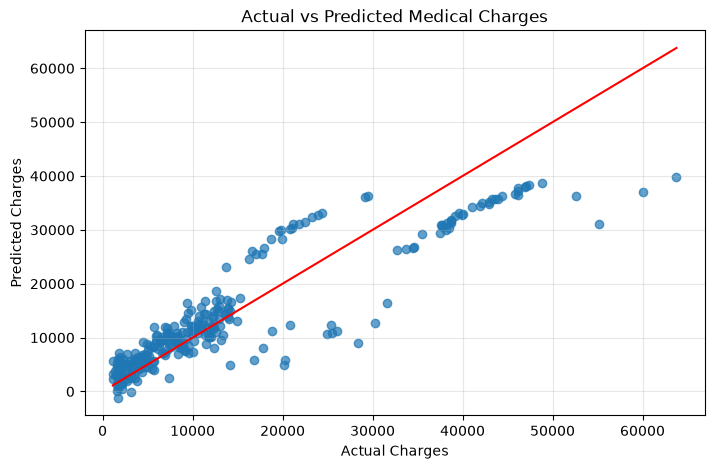

In [59]:
# Create figure
plt.figure(figsize = (8, 5))

# Plot actual vs predicted
plt.scatter(

    y_test,

    predicted_charges,

    alpha = 0.7)

# Plot reference line
plt.plot(

    [y_test.min(), y_test.max()],

    [y_test.min(), y_test.max()],

    color = 'red')

# Chart title
plt.title('Actual vs Predicted Medical Charges')

# X-axis label
plt.xlabel('Actual Charges')

# Y-axis label
plt.ylabel('Predicted Charges')

# Show grid
plt.grid(alpha = 0.3)

# Display chart
plt.show()

#### Prediction Error Distribution

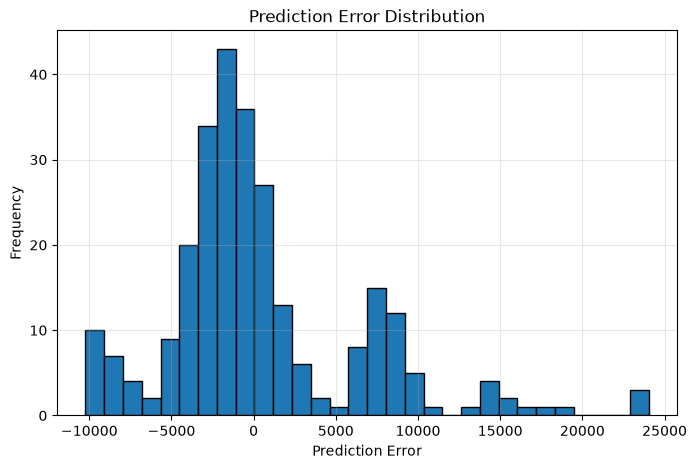

In [60]:
# Create figure
plt.figure(figsize = (8, 5))

# Plot prediction error distribution
plt.hist(

    prediction_results['Prediction Error'],

    bins = 30,

    edgecolor = 'black')

# Chart title
plt.title('Prediction Error Distribution')

# X-axis label
plt.xlabel('Prediction Error')

# Y-axis label
plt.ylabel('Frequency')

# Show grid
plt.grid(alpha = 0.3)

# Display chart
plt.show()

#### Actual vs Predicted Comparison

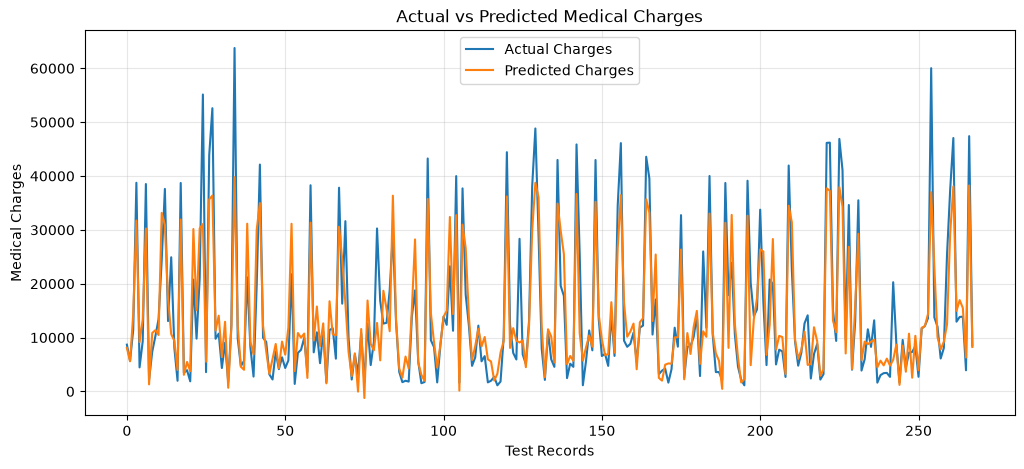

In [61]:
# Create figure
plt.figure(figsize = (12, 5))

# Plot actual charges
plt.plot(

    y_test.values,

    label = 'Actual Charges')

# Plot predicted charges
plt.plot(

    predicted_charges,

    label = 'Predicted Charges')

# Chart title
plt.title('Actual vs Predicted Medical Charges')

# X-axis label
plt.xlabel('Test Records')

# Y-axis label
plt.ylabel('Medical Charges')

# Show legend
plt.legend()

# Show grid
plt.grid(alpha = 0.3)

# Display chart
plt.show()

#### Residual Plot

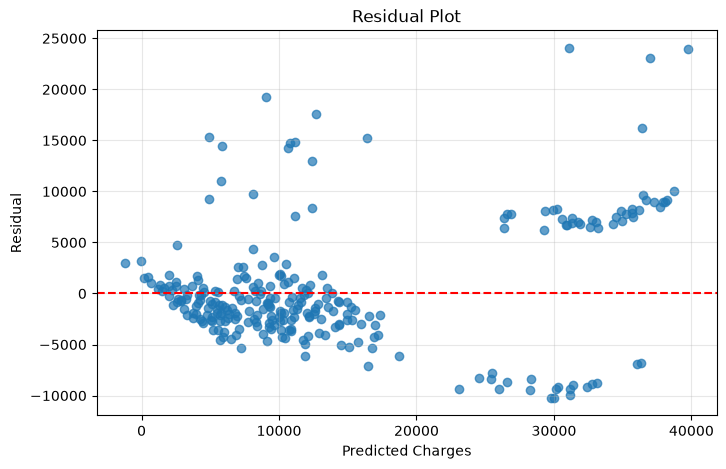

In [62]:
# Create figure
plt.figure(figsize = (8, 5))

# Plot residuals
plt.scatter(

    predicted_charges,

    prediction_results['Prediction Error'],

    alpha = 0.7)

# Reference line
plt.axhline(

    y = 0,

    linestyle = '--',

    color = 'red')

# Chart title
plt.title('Residual Plot')

# X-axis label
plt.xlabel('Predicted Charges')

# Y-axis label
plt.ylabel('Residual')

# Show grid
plt.grid(alpha = 0.3)

# Display chart
plt.show()

#### BMI vs Charges Scatter Plot

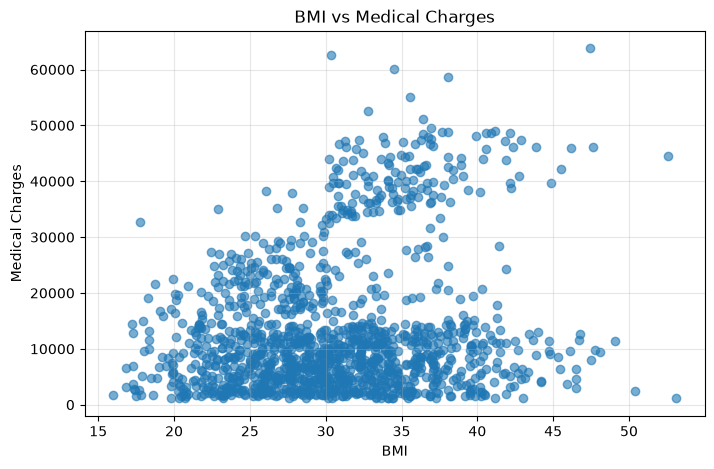

In [63]:
# Create figure
plt.figure(figsize = (8, 5))

# Plot BMI vs Medical Charges
plt.scatter(

    insurance_data['bmi'],

    insurance_data['charges'],

    alpha = 0.6)

# Chart title
plt.title('BMI vs Medical Charges')

# X-axis label
plt.xlabel('BMI')

# Y-axis label
plt.ylabel('Medical Charges')

# Show grid
plt.grid(alpha = 0.3)

# Display chart
plt.show()

#### Age vs Charges Scatter Plot

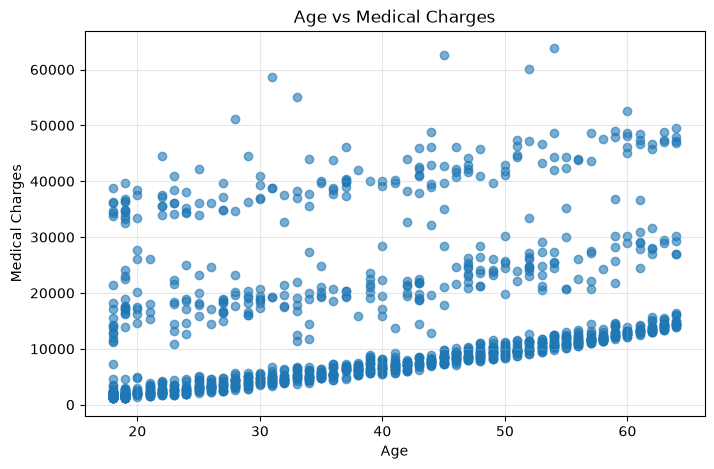

In [64]:
# Create figure
plt.figure(figsize = (8, 5))

# Plot Age vs Medical Charges
plt.scatter(

    insurance_data['age'],

    insurance_data['charges'],

    alpha = 0.6)

# Chart title
plt.title('Age vs Medical Charges')

# X-axis label
plt.xlabel('Age')

# Y-axis label
plt.ylabel('Medical Charges')

# Show grid
plt.grid(alpha = 0.3)

# Display chart
plt.show()

#### Feature Coefficients

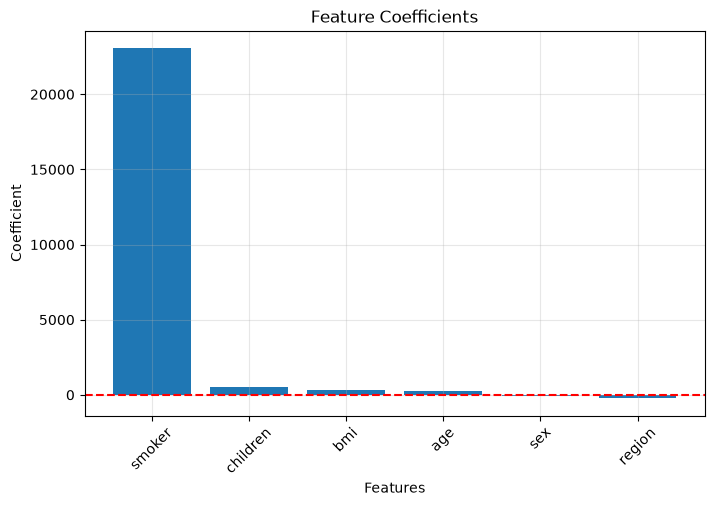

In [65]:
# Create figure
plt.figure(figsize = (8, 5))

# Plot feature coefficients
plt.bar(

    coefficients['Feature'],

    coefficients['Coefficient'])

plt.axhline(

    y = 0,

    linestyle = '--',

    color = 'red')

# Chart title
plt.title('Feature Coefficients')

# X-axis label
plt.xlabel('Features')

# Y-axis label
plt.ylabel('Coefficient')

# Rotate x-axis labels
plt.xticks(rotation = 45)

# Show grid
plt.grid(alpha = 0.3)

# Display chart
plt.show()

#### Feature Importance Summary

In [66]:
# Display feature importance
coefficients

,Feature,Coefficient
4,smoker,23052.152752
3,children,534.120877
2,bmi,312.609045
0,age,248.764071
1,sex,-99.695394
5,region,-237.625147


#### Prediction Error Trend

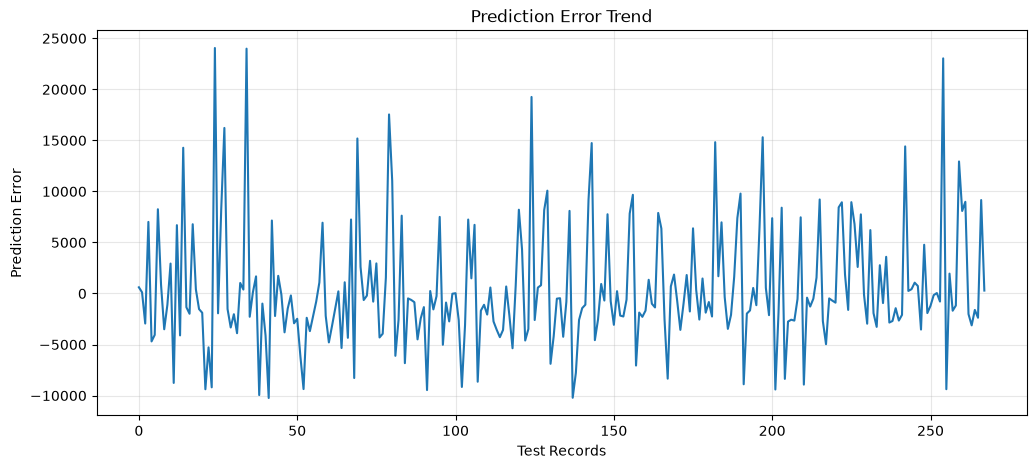

In [67]:
# Create figure
plt.figure(figsize = (12, 5))

# Plot prediction error
plt.plot(

    prediction_results['Prediction Error'])

# Chart title
plt.title('Prediction Error Trend')

# X-axis label
plt.xlabel('Test Records')

# Y-axis label
plt.ylabel('Prediction Error')

# Show grid
plt.grid(alpha = 0.3)

# Display chart
plt.show()

#### Evaluation Metrics Summary

In [68]:
# Display evaluation metrics
evaluation_results

,Metric,Value
0,MAE,4.182353e+03
1,MSE,3.549310e+07
2,RMSE,5.957609e+03
3,R² Score,8.068466e-01
4,MAPE (%),4.179273e+01


### Step 8 :- Information

> Project Name: Medical Cost Prediction

> Dataset: insurance.csv

> Problem Type: Regression

> Machine Learning Algorithm: Linear Regression

> Programming Language: Python

> Libraries Used:
> - Pandas
> - NumPy
> - Matplotlib
> - Scikit-learn

> Target Variable: charges

> Input Features:
> - age
> - sex
> - bmi
> - children
> - smoker
> - region

> Total Records: 1337

> Total Columns: 7

> Input Features: 6

> Target Variable: 1

> Training Records: 1069

> Testing Records: 268

> Train-Test Split:
> - 80% Training
> - 20% Testing

> Training R² Score: 0.7297

> Testing R² Score: 0.8068

> Evaluation Metrics:
> - MAE
> - MSE
> - RMSE
> - R² Score
> - MAPE

> Average Prediction Error: 4182.35

> Maximum Prediction Error: 24052.35

### Step 9 :- Data Insights

> The dataset contains 1,337 medical insurance records.

> There are 6 input features and 1 target variable.

> No missing values are present in the dataset.

> One duplicate record was identified and removed.

> The average medical insurance charge is approximately 13,270.

> Medical charges range from approximately 1,122 to 63,770.

> Most customers are non-smokers.

> The Southeast region contains the highest number of customers.

> Age has a moderate positive relationship with medical charges.

> BMI has a weak positive relationship with medical charges.

> The smoker feature has the strongest influence on medical insurance charges.

> Customers who smoke generally have significantly higher medical insurance charges than non-smokers.

### Step 10 :- Model Insights

> Linear Regression successfully learned the relationship between customer characteristics and medical charges.

> The model achieved a Training R² Score of 0.7297.

> The model achieved a Testing R² Score of 0.8068.

> The model explains approximately 81% of the variation in medical insurance charges.

> Smoking status is the most important feature for predicting medical costs.

> BMI, age, and number of children also contribute to medical cost prediction.

> The prediction accuracy is good for a baseline Linear Regression model.

> The model performs better on general medical cost patterns than on extreme high-cost cases.

> The model can be further improved using advanced machine learning algorithms.

### Step 11 :- Risks

> The model assumes a linear relationship between input features and medical charges.

> Important medical factors such as chronic diseases, medical history, and lifestyle are not included.

> Healthcare costs may change over time due to inflation and policy updates.

> Prediction accuracy may decrease for unseen customer profiles.

> Extreme medical expenses may be difficult to predict accurately.

> The model may require periodic retraining using updated insurance data.

### Step 12 :- Opportunities

> Predict future medical insurance costs for customers.

> Help insurance companies estimate premiums more accurately.

> Support risk assessment during customer onboarding.

> Improve pricing strategies for health insurance policies.

> Assist healthcare organizations in financial planning.

> Integrate the model into insurance management systems.

### Step 13 :- Recommendations

> Increase the dataset size to improve model performance.

> Include additional features such as medical history, chronic diseases, exercise habits, and income.

> Compare Linear Regression with Random Forest, XGBoost, and Gradient Boosting.

> Perform feature engineering to improve prediction accuracy.

> Monitor model performance regularly.

> Retrain the model using updated insurance data.

> Validate the model using Cross Validation before deployment.

### Step 14 :- Future Improvements

> Build a Random Forest Regression model.

> Build an XGBoost Regression model.

> Perform Hyperparameter Tuning.

> Apply Cross Validation.

> Develop a Medical Cost Prediction Dashboard.

> Deploy the model using Streamlit or Flask.

> Integrate the model with real-time insurance data.

> Build an AI-powered medical insurance recommendation system.